# Naive Bayes Classification – NBA Player Longevity Prediction

## Step 1: Import Required Libraries

# 

In [3]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Here are my model evaluation  libraries
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

## Step 2: Load the Dataset

In [5]:
# Creating the file path 
path = "C:\\Users\\DajahV01\\Desktop\\DHF Assignment\\Naive Bayes Classification – NBA Player Longevity Prediction\\extracted_nba_players_data.csv.csv"

# Load dataset
df = pd.read_csv(path)

# Preview the first 5 columns of the dataset
df.head()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
0,34.7,25.0,69.9,4.1,1.9,0.4,0.4,1.3,0,266.4,0.270073
1,29.6,23.5,76.5,2.4,3.7,1.1,0.5,1.6,0,252.0,0.267658
2,42.2,24.4,67.0,2.2,1.0,0.5,0.3,1.0,0,384.8,0.339869
3,42.6,22.6,68.9,1.9,0.8,0.6,0.1,1.0,1,330.6,0.491379
4,52.4,0.0,67.4,2.5,0.3,0.3,0.4,0.8,1,216.0,0.391304


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB


In [8]:
# Statistical summary of the dataset

df.describe()

,fg,3p,ft,reb,ast,stl,blk,tov,target_5yrs,total_points,efficiency
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,44.169403,19.149627,70.300299,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149,451.783358,0.371078
std,6.137679,16.051861,10.578479,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531,366.520093,0.093659
min,23.800000,0.000000,0.000000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000,14.700000,0.121951
25%,40.200000,0.000000,64.700000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000,172.800000,0.306710
50%,44.100000,22.200000,71.250000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000,338.350000,0.363325
75%,47.900000,32.500000,77.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000,639.675000,0.431326
max,73.700000,100.000000,100.000000,13.900000,10.600000,2.500000,3.900000,4.400000,1.000000,2312.400000,0.738462


In [9]:
# Check missing values

df.isnull().sum()

fg              0
3p              0
ft              0
reb             0
ast             0
stl             0
blk             0
tov             0
target_5yrs     0
total_points    0
efficiency      0
dtype: int64

### Expected observation:

* No missing values
* All predictor variables are numerical
* target_5yrs is the binary target variable

## Step 4: Define Features and Target

In [10]:
X = df.drop("target_5yrs", axis=1)

y = df["target_5yrs"]

## Step 5: Train-Test Split

Using an 80-20 split.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

##  Step 6: Build the Gaussian Naive Bayes Model

In [13]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

## Step 7: Make Predictions

In [14]:
y_pred = model.predict(X_test)

## Step 8: Confusion Matrix

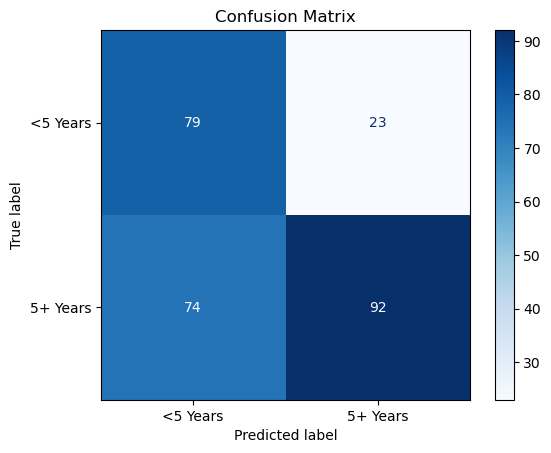

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["<5 Years", "5+ Years"]
)

disp.plot(cmap = "Blues")

plt.title("Confusion Matrix")

plt.show()

## Step 9: Model Performance

**Accuracy**

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6380597014925373


**Precision**

In [22]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.8


**Interpretation:**

* Precision measures the proportion of players predicted to survive five years who actually do survive five years. High precision minimizes false positives, reducing the chance of scouting players who ultimately become unsuccessful.

**Recall**

In [23]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.5542168674698795


***Interpretation:**

* Recall measures the proportion of actual long-career players correctly identified by the model. High recall minimizes false negatives, reducing the likelihood of overlooking talented players.

## Full Classification Report

In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.77      0.62       102
           1       0.80      0.55      0.65       166

    accuracy                           0.64       268
   macro avg       0.66      0.66      0.64       268
weighted avg       0.69      0.64      0.64       268



## Step 10: Feature Correlation

Although Gaussian Naive Bayes assumes feature independence, basketball statistics are often correlated.

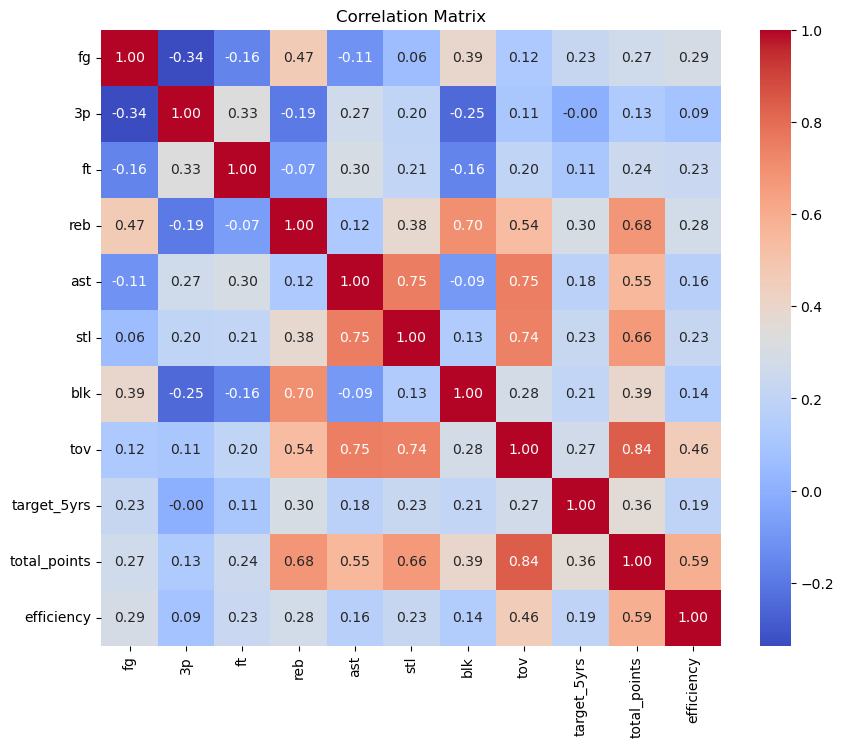

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Step 11: Identify Important Features

Unlike Decision Trees or Random Forests, Gaussian Naive Bayes does not provide feature importance directly.


Instead it examine correlations with the target.

In [29]:
correlation = df.corr()["target_5yrs"].sort_values(ascending = False)

print(correlation)

target_5yrs     1.000000
total_points    0.358493
reb             0.299406
tov             0.272348
stl             0.229811
fg              0.227134
blk             0.210114
efficiency      0.194486
ast             0.175353
ft              0.106706
3p             -0.000004
Name: target_5yrs, dtype: float64


## Step 12: Explain the Independence Assumption
Naive Bayes Independence Assumption

Gaussian Naive Bayes assumes that every predictor variable is conditionally independent of every other predictor given the class label.

Mathematically,



$$
P(X_1, X_2, \ldots, X_n \mid Y)
=
\prod_{i=1}^{n} P(X_i \mid Y)
$$

**where:**

- \(X_1, X_2, ..., X_n\) are the predictor variables (e.g., `total_points`, `reb`, `tov`, `stl`, `fg` etc.).
- \(Y\) represents the target class (`target_5yrs`).
- \(P(X_i \mid Y)\) is the conditional probability of observing feature \(X_i\) given the class \(Y\).



This assumption greatly simplifies probability estimation and enables fast model training.

Is this realistic for NBA statistics?

Not entirely.

Many basketball statistics are naturally correlated.

Examples include:

* More playing time generally leads to more points.
* More minutes often result in more rebounds.
* High scorers usually attempt more field goals.
* Assists and points frequently increase together for primary ball handlers.

**Because of these relationships, the independence assumption is violated.**

Despite this limitation, Gaussian Naive Bayes often performs surprisingly well because it estimates class probabilities robustly even when predictors exhibit moderate correlation.










## Step 13: Business Interpretation

**Reliability**

The model provides a fast and computationally efficient method for predicting whether an NBA player is likely to remain in the league for at least five years.

It performs well as an initial screening tool for player evaluation.






**Recommendations**

For a scouting department:

* Use Gaussian Naive Bayes as a first-pass screening model.
* Combine predictions with expert scouting reports.
* Validate predictions using additional models such as Random Forest or XGBoost.
* Continuously retrain the model with updated player performance data.
* Focus on maximizing recall if the priority is identifying future stars while accepting some false positives.

## Step 14: Final Conclusion



A Gaussian Naive Bayes classifier was successfully developed to predict NBA player career longevity. The model was trained using continuous player performance metrics and evaluated using a confusion matrix, precision, recall, and accuracy. While the model offers rapid predictions and interpretable probabilistic outputs, its assumption that player statistics are independent is unrealistic because many basketball metrics are naturally correlated. Consequently, Gaussian Naive Bayes is best suited as an initial decision-support tool rather than a standalone scouting solution. Integrating its predictions with expert evaluation and more sophisticated machine learning models can significantly improve long-term talent identification.